In [4]:
from google.colab import files
import pandas as pd
import io

print("--- File Upload Code ---")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f"\n File '{filename}' successfully uploaded!")


  break

--- File Upload Code ---


Saving StressLevelDataset.csv to StressLevelDataset.csv

 File 'StressLevelDataset.csv' successfully uploaded!


In [5]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')



FILE_NAME = 'StressLevelDataset.csv'
df = pd.read_csv(FILE_NAME)



NUMERICAL_FEATS = ['anxiety_level', 'self_esteem', 'depression', 'headache', 'blood_pressure',
                   'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions',
                   'safety', 'basic_needs', 'academic_performance', 'study_load',
                   'teacher_student_relationship', 'future_career_concerns',
                   'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']


for col in NUMERICAL_FEATS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()


df['Burnout_Status'] = np.where(df['stress_level'] == 2, 1, 0)
FINAL_TARGET_COL = 'Burnout_Status'


X = df[NUMERICAL_FEATS]
y = df[FINAL_TARGET_COL]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Total Training Samples: {len(X_train)}")

Total Training Samples: 880


In [6]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATS)
    ],
    remainder='passthrough'
)


models = {
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'SVC': SVC(random_state=42, probability=True)
}


param_grids = {
    'XGBoost': {'classifier__n_estimators': [300, 500], 'classifier__max_depth': [4, 6], 'classifier__learning_rate': [0.05, 0.1]},
    'RandomForest': {'classifier__n_estimators': [200, 400], 'classifier__max_depth': [10, 20]},
    'SVC': {'classifier__C': [0.1, 1], 'classifier__kernel': ['rbf', 'linear']}
}

results = []
best_accuracy = 0
best_model_name = ""
best_final_model = None




for name, model in models.items():
    print(f"\nTraining {name}...")


    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', SMOTE(random_state=42)),
        ('classifier', model)
    ])


    grid_search = GridSearchCV(pipeline, param_grids[name], cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)


    y_pred = grid_search.best_estimator_.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}",
        'Best Params': grid_search.best_params_
    })


    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_final_model = grid_search.best_estimator_
        best_cm = cm

    print(f"   Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)


print(results_df.to_markdown(index=False))

print(f"\n The Best Model is: **{best_model_name}** with Accuracy: {best_accuracy:.4f}")


Training XGBoost...
   Accuracy: 0.9364 | F1-Score: 0.9014

Training RandomForest...
   Accuracy: 0.9273 | F1-Score: 0.8841

Training SVC...
   Accuracy: 0.9273 | F1-Score: 0.8788
| Model        |   Accuracy |   Precision |   Recall |   F1-Score | Best Params                                                                                     |
|:-------------|-----------:|------------:|---------:|-----------:|:------------------------------------------------------------------------------------------------|
| XGBoost      |     0.9364 |      0.9412 |   0.8649 |     0.9014 | {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 500} |
| RandomForest |     0.9273 |      0.9531 |   0.8243 |     0.8841 | {'classifier__max_depth': 20, 'classifier__n_estimators': 400}                                  |
| SVC          |     0.9273 |      1      |   0.7838 |     0.8788 | {'classifier__C': 0.1, 'classifier__kernel': 'rbf'}                                    

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

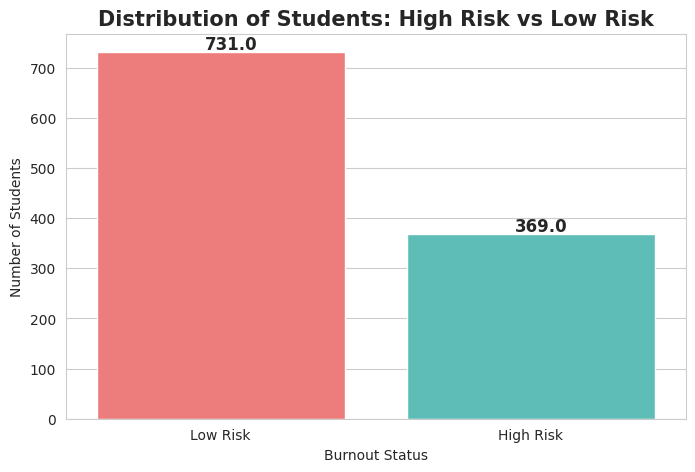

In [8]:

viz_df = df.copy()

viz_df['Burnout_Status'] = viz_df['stress_level'].apply(lambda x: 'High Risk' if x == 2 else 'Low Risk')

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Burnout_Status', data=viz_df, palette=['#ff6b6b', '#4ecdc4'])
plt.title('Distribution of Students: High Risk vs Low Risk', fontsize=15, fontweight='bold')
plt.xlabel('Burnout Status')
plt.ylabel('Number of Students')


for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 5), fontsize=12, fontweight='bold')

plt.show()

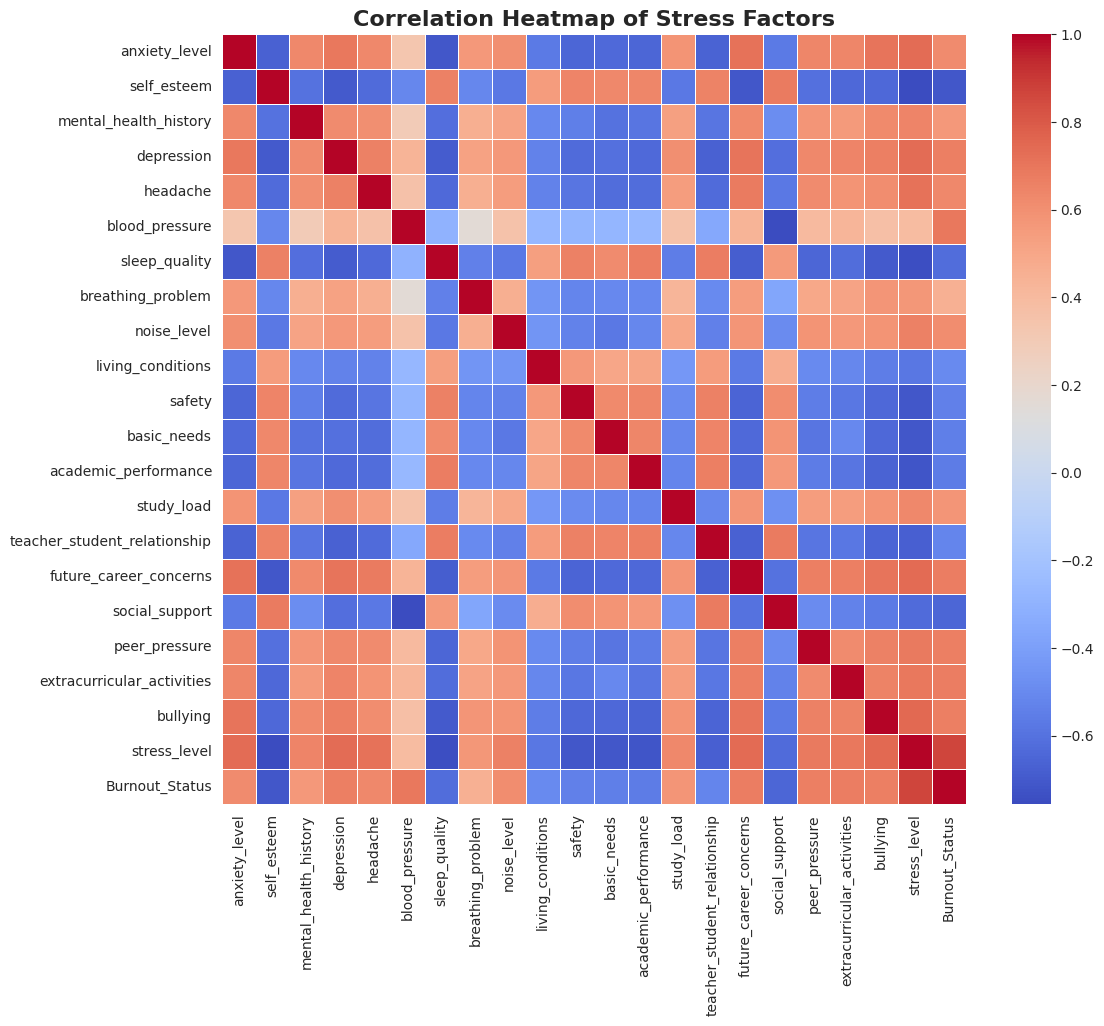

In [9]:
plt.figure(figsize=(12, 10))

corr_matrix = df.corr()


sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Stress Factors', fontsize=16, fontweight='bold')
plt.show()

In [ ]:

model_filename = f'{best_model_name}_Final_Burnout_Predictor.pkl'
try:
    with open(model_filename, 'wb') as file:
        pickle.dump(best_final_model, file)
    print(f"\n Final Best Model successfully saved as: **{model_filename}**.")

    from google.colab import files
    files.download(model_filename)

except Exception as e:
    print(f" Error saving model: {e}")




PREDICTION_CODE = f"""
import pickle
import numpy as np
import pandas as pd


MODEL_FILE = '{best_model_name}_Final_Burnout_Predictor.pkl'
with open(MODEL_FILE, 'rb') as file:
    loaded_model = pickle.load(file)

def predict_burnout(input_values):

    # Features  order: {NUMERICAL_FEATS}



    input_df = pd.DataFrame([input_values], columns={NUMERICAL_FEATS})


    prediction = loaded_model.predict(input_df)[0]


    try:
        proba = loaded_model.predict_proba(input_df)[0][1]
    except:
        proba = 'N/A'

    if prediction == 1:
        status = "High Burnout Risk"
    else:
        status = "Low Burnout Risk"

    return status, proba


sample_input = [18, 5, 17, 4, 3, 1, 4, 3, 2, 2, 1, 2, 5, 2, 5, 1, 4, 4, 5]

status, proba = predict_burnout(sample_input)

print(f"Input Features: {{len(sample_input)}} values")
print(f"Predicted Status: {{status}}")
print(f"Burnout Probability: {{proba:.2f}}" if isinstance(proba, float) else f"Burnout Probability: {{proba}}")
"""

print(PREDICTION_CODE)


 Final Best Model successfully saved as: **XGBoost_Final_Burnout_Predictor.pkl**.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


import pickle
import numpy as np
import pandas as pd


MODEL_FILE = 'XGBoost_Final_Burnout_Predictor.pkl'
with open(MODEL_FILE, 'rb') as file:
    loaded_model = pickle.load(file)

def predict_burnout(input_values):

    # Features  order: ['anxiety_level', 'self_esteem', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']



    input_df = pd.DataFrame([input_values], columns=['anxiety_level', 'self_esteem', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying'])


   

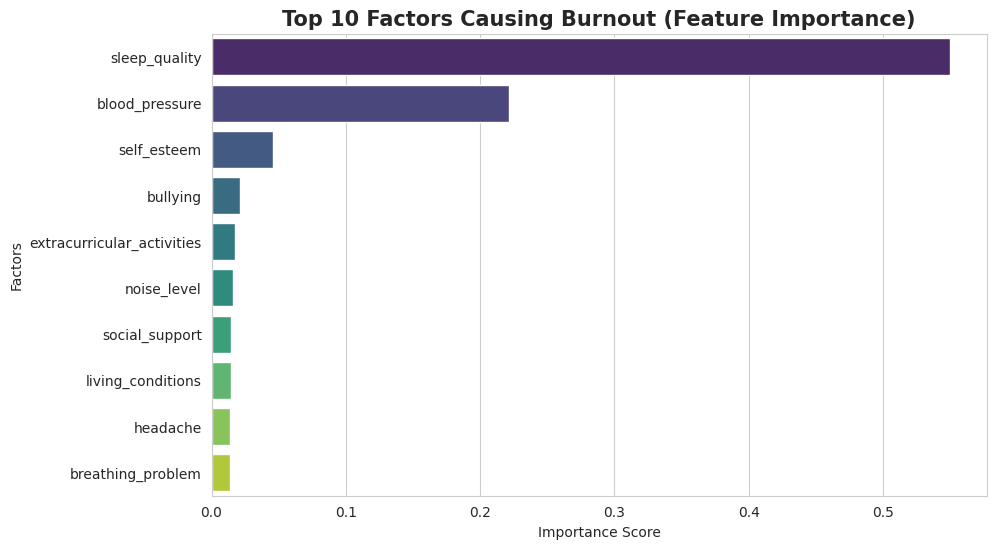

In [14]:

feature_importances = best_final_model.named_steps['classifier'].feature_importances_
feature_names = X.columns


fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 features


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Top 10 Factors Causing Burnout (Feature Importance)', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Factors')
plt.show()

<Figure size 800x600 with 0 Axes>

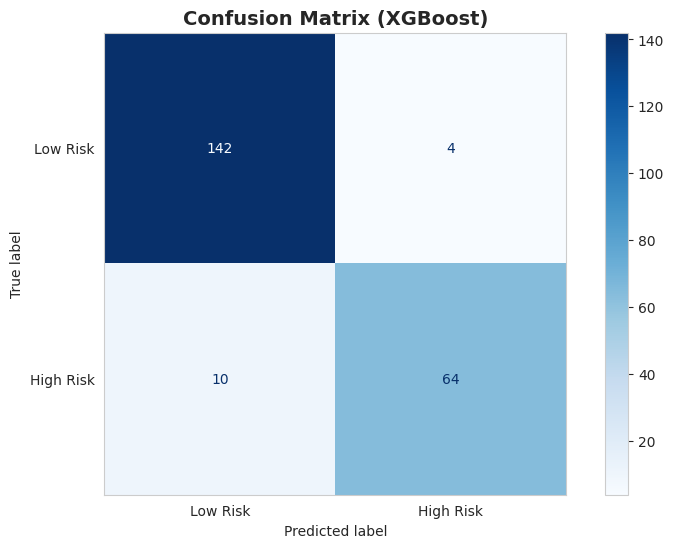

In [15]:

y_pred = best_final_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])


plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (XGBoost)', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

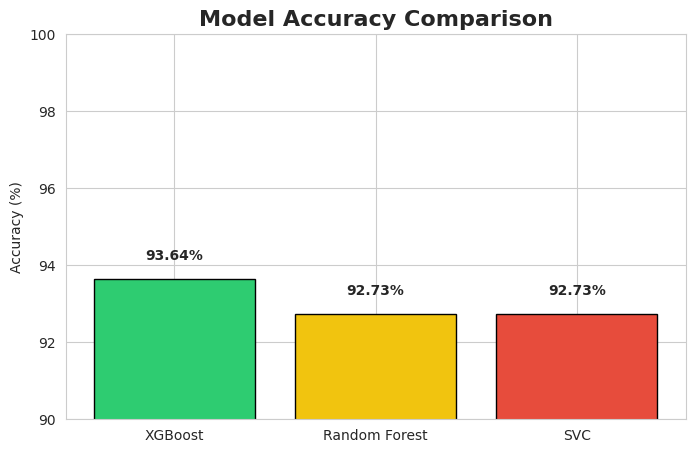

In [16]:

models = ['XGBoost', 'Random Forest', 'SVC']
accuracies = [93.64, 92.73, 92.73]
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', fontweight='bold')

plt.ylim(90, 100)
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.show()